In [3]:
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt

In [4]:
gas_plants = gpd.read_file("Manufactured_Gas_Plant_Sites.geojson")
counties = gpd.read_file("North_Carolina_State_and_County_Boundary_Polygons.geojson")
watersheds = gpd.read_file("dwq_wsws_20141126_-1629323221143849216.geojson")
benthos = gpd.read_file("NC_DWR_Benthos_Sample_Results.geojson")
water_report = pd.read_csv("Water System Summary_20261008.csv")

In [5]:
watersheds = watersheds.to_crs(epsg=2264)

In [6]:
watersheds.crs

<Projected CRS: EPSG:2264>
Name: NAD83 / North Carolina (ftUS)
Axis Info [cartesian]:
- X[east]: Easting (US survey foot)
- Y[north]: Northing (US survey foot)
Area of Use:
- name: United States (USA) - North Carolina - counties of Alamance; Alexander; Alleghany; Anson; Ashe; Avery; Beaufort; Bertie; Bladen; Brunswick; Buncombe; Burke; Cabarrus; Caldwell; Camden; Carteret; Caswell; Catawba; Chatham; Cherokee; Chowan; Clay; Cleveland; Columbus; Craven; Cumberland; Currituck; Dare; Davidson; Davie; Duplin; Durham; Edgecombe; Forsyth; Franklin; Gaston; Gates; Graham; Granville; Greene; Guilford; Halifax; Harnett; Haywood; Henderson; Hertford; Hoke; Hyde; Iredell; Jackson; Johnston; Jones; Lee; Lenoir; Lincoln; Macon; Madison; Martin; McDowell; Mecklenburg; Mitchell; Montgomery; Moore; Nash; New Hanover; Northampton; Onslow; Orange; Pamlico; Pasquotank; Pender; Perquimans; Person; Pitt; Polk; Randolph; Richmond; Robeson; Rockingham; Rowan; Rutherford; Sampson; Scotland; Stanly; Stokes; Sur

In [7]:
gas_plants = gas_plants.to_crs(epsg=2264)

In [8]:
counties = counties.to_crs(epsg=2264)

In [9]:
benthos = benthos.to_crs(epsg=2264)

In [10]:
plants_in_watersheds = gpd.sjoin(gas_plants, watersheds, predicate= "within")
len(plants_in_watersheds)
plants_in_watersheds

,objectid,epaid,sitename,cerclis_n,siteaddr,sitecity,sitecounty,yrs_op,lead_rp,status,...,index_right,OBJECTID,class,STREAM_NAM,CL_DATE,PCA_TYPE,WSWS_PCA,ClassURL,Area_acers,SecClass
15,16,NONCD0001085,Hickory MGP,Hickory Coal Gas Plant,625 12th Street Drive NW,Hickory,Catawba,1933-1948,PNG,I,...,316,317,WS-IV,Lake Hickory,8/3/92,P,WS-IVP,http://deq.nc.gov/about/divisions/water-resour...,15332.201671,None
16,17,NCD986188837,High Point MGP,High Point Coal Gas Plant,Centennial St and Kivett Drive,High Point,Guilford,1912-1948,Duke Power,I,...,281,282,WS-IV,Deep River (Randleman Lake),9/1/74,P,WS-IVP,http://deq.nc.gov/about/divisions/water-resour...,25022.565530,None


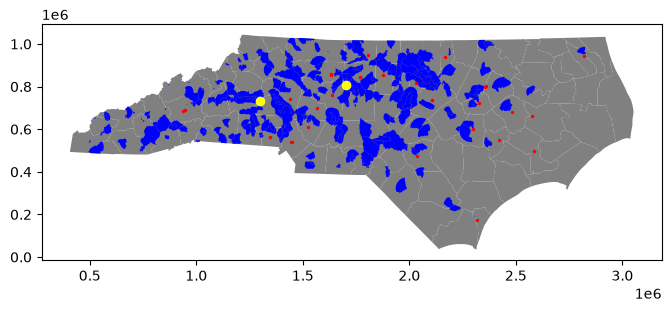

In [11]:
fig, ax = plt.subplots(figsize=(8,7))
counties.plot(ax=ax, color="grey")
watersheds.plot(ax=ax, color="blue")
gas_plants.plot(ax=ax, markersize=2, color="red")
plants_in_watersheds.plot(ax=ax, color="yellow")
plt.show()

It was at this point in the data analysis at which I decided to add the benthos data, originally I only planned on using the gas plants, water supply sheds, and counties data in my original homework plan. I realized the gas plant dataframe already had county information so the counties layer wasn't useful for much other than mapping. It decided it would be useful for capturing the whole picture of the quality of the water within these watersheds. I also decided the water report would be useful to fulfill the tabular join requirement, as well as speak to the quality of the water supply watersheds, and inspect whether there was correlation between violations, poor benthos, and gas site locations. I used ChatGPT to recommend the benthos and water quality data

I decided since the 2 gas plants within watersheds were in Guilford and Catawba, to filter the benthos data for Guilford and Catawba county

In [12]:
CG_benthos = benthos[benthos["County"].isin(["Guilford", "Catawba"])]
CG_benthos

,Site_ID,View_Details,Water_Body,Location,County,Sampled_Rating,Longitude,Latitude,Latest_Rating,Study_Type,ObjectId,geometry
8,CB193,"<a href=""http://www.ncwater.org/?page=672&Site...",MAIDEN CR,OFF SR 1892,Catawba,<br />18 Mar 1993 / Good,-81.172359,35.594106,Good,N/A,10,POINT (1354239.099 678219.603)
10,CB194,"<a href=""http://www.ncwater.org/?page=672&Site...",MAIDEN CR,SR 1858,Catawba,<br />18 Mar 1993 / Good,-81.150716,35.607076,Good,N/A,12,POINT (1360752.884 682779.392)
12,CB196,"<a href=""http://www.ncwater.org/?page=672&Site...",PINCH GUT CR,SR 2007,Catawba,<br />17 Apr 2001 / Good<br />11 Sep 1984 / Go...,-81.225556,35.586111,Good,Special Study,14,POINT (1338359.464 675661.414)
17,CB199,"<a href=""http://www.ncwater.org/?page=672&Site...",S FK CATAWBA R,NC 10,Catawba,<br />18 Aug 1997 / Good<br />17 Aug 1992 / Go...,-81.305556,35.632778,Good,Basin Sample,19,POINT (1314987.226 693236.053)
33,BB004,"<a href=""http://www.ncwater.org/?page=672&Site...",CANDY CR,SR 2700,Guilford,<br />11 Jun 1990 / Fair<br />05 Jun 1985 / Fair,-79.661389,36.233611,Fair,N/A,36,POINT (1804929.492 904592.021)
...,...,...,...,...,...,...,...,...,...,...,...,...
1617,BB531,"<a href=""http://www.ncwater.org/?page=672&Site...",UT DEEP R,CHATFIELD DR,Guilford,<br />07 May 2015 / Fair,-79.936330,35.972420,Fair,Special Study,1691,POINT (1722943.435 810165.28)
1619,BB533,"<a href=""http://www.ncwater.org/?page=672&Site...",UT RYAN CR,FRIENDLY RD,Guilford,<br />06 May 2016 / Poor,-79.821950,36.021840,Poor,Special Study,1693,POINT (1756936.179 827854.911)
1634,CB301,"<a href=""http://www.ncwater.org/?page=672&Site...",JACOB FK,NC 127,Catawba,<br />18 Jun 2007 / Good,-81.380833,35.645556,Good,Special Study,1708,POINT (1292724.246 698362.75)
1635,CB302,"<a href=""http://www.ncwater.org/?page=672&Site...",SNOW CR,SR 1507,Catawba,<br />19 Jun 2007 / Good-Fair,-81.285556,35.786667,Good-Fair,Special Study,1709,POINT (1322205.591 749046.375)


Lets see if we can join this with the plants_in_watersheds data

In [13]:
plants_benthos_inwatersheds = gpd.sjoin(CG_benthos, plants_in_watersheds, predicate="touches")

ValueError: 'index_right' cannot be a column name in the frames being joined

This was a code error I kept getting because I kept joining dataframes that had been made from a spatial join, I asked ChatGPT for the code that would fix it.

In [ ]:
plants_in_watersheds = plants_in_watersheds.drop(columns="index_right")

In [ ]:
plants_benthos_inwatersheds = gpd.sjoin(CG_benthos, plants_in_watersheds, predicate="touches")
plants_benthos_inwatersheds

,Site_ID,View_Details,Water_Body,Location,County,Sampled_Rating,Longitude,Latitude,Latest_Rating,Study_Type,...,status,OBJECTID,class,STREAM_NAM,CL_DATE,PCA_TYPE,WSWS_PCA,ClassURL,Area_acers,SecClass


Wanted to check the spatial relationship:

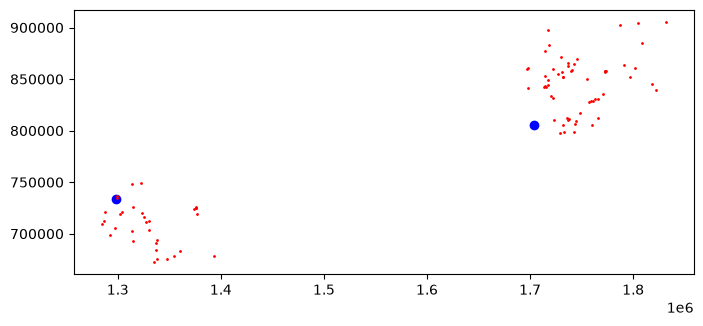

In [ ]:
fig, ax = plt.subplots(figsize=(8,7))
plants_in_watersheds.plot(ax=ax, color="blue")
CG_benthos.plot(ax=ax, markersize=1, color="red")
plt.show()

Looks like one in Catawba touches, but still didn't match up. Maybe lets see how close the nearest benthos assessments are. I used code from this link:https://medium.com/@Nexumo_/7-geopandas-shapely-tricks-for-real-world-geospatial-analytics-931bad1cb79f

In [ ]:

plants_benthos_inwatersheds = gpd.sjoin_nearest(plants_in_watersheds, CG_benthos, how="left", distance_col="feet")
plants_benthos_inwatersheds

,objectid,epaid,sitename,cerclis_n,siteaddr,sitecity,sitecounty,yrs_op,lead_rp,status,...,Location,County,Sampled_Rating,Longitude,Latitude,Latest_Rating,Study_Type,ObjectId,buffer,feet
15,16,NONCD0001085,Hickory MGP,Hickory Coal Gas Plant,625 12th Street Drive NW,Hickory,Catawba,1933-1948,PNG,I,...,SR 1314,Catawba,<br />29 Apr 2019 / Fair,-81.36130,35.74514,Fair,Special Study,353,POLYGON EMPTY,1579.280129
16,17,NCD986188837,High Point MGP,High Point Coal Gas Plant,Centennial St and Kivett Drive,High Point,Guilford,1912-1948,Duke Power,I,...,CHATFIELD DR,Guilford,<br />07 May 2015 / Fair,-79.93633,35.97242,Fair,Special Study,1691,POLYGON EMPTY,19591.456955


In [ ]:
benthos_near_plants = gpd.sjoin_nearest(CG_benthos, plants_in_watersheds, how="left", distance_col="feet")
benthos_near_plants

,Site_ID,View_Details,Water_Body,Location,County,Sampled_Rating,Longitude,Latitude,Latest_Rating,Study_Type,...,OBJECTID,class,STREAM_NAM,CL_DATE,PCA_TYPE,WSWS_PCA,ClassURL,Area_acers,SecClass,feet
8,CB193,"<a href=""http://www.ncwater.org/?page=672&Site...",MAIDEN CR,OFF SR 1892,Catawba,<br />18 Mar 1993 / Good,-81.172359,35.594106,Good,N/A,...,317,WS-IV,Lake Hickory,8/3/92,P,WS-IVP,http://deq.nc.gov/about/divisions/water-resour...,15332.201671,None,78706.212079
10,CB194,"<a href=""http://www.ncwater.org/?page=672&Site...",MAIDEN CR,SR 1858,Catawba,<br />18 Mar 1993 / Good,-81.150716,35.607076,Good,N/A,...,317,WS-IV,Lake Hickory,8/3/92,P,WS-IVP,http://deq.nc.gov/about/divisions/water-resour...,15332.201671,None,80527.039177
12,CB196,"<a href=""http://www.ncwater.org/?page=672&Site...",PINCH GUT CR,SR 2007,Catawba,<br />17 Apr 2001 / Good<br />11 Sep 1984 / Go...,-81.225556,35.586111,Good,Special Study,...,317,WS-IV,Lake Hickory,8/3/92,P,WS-IVP,http://deq.nc.gov/about/divisions/water-resour...,15332.201671,None,70393.734385
17,CB199,"<a href=""http://www.ncwater.org/?page=672&Site...",S FK CATAWBA R,NC 10,Catawba,<br />18 Aug 1997 / Good<br />17 Aug 1992 / Go...,-81.305556,35.632778,Good,Basin Sample,...,317,WS-IV,Lake Hickory,8/3/92,P,WS-IVP,http://deq.nc.gov/about/divisions/water-resour...,15332.201671,None,43593.357219
33,BB004,"<a href=""http://www.ncwater.org/?page=672&Site...",CANDY CR,SR 2700,Guilford,<br />11 Jun 1990 / Fair<br />05 Jun 1985 / Fair,-79.661389,36.233611,Fair,N/A,...,282,WS-IV,Deep River (Randleman Lake),9/1/74,P,WS-IVP,http://deq.nc.gov/about/divisions/water-resour...,25022.565530,None,141315.644815
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1617,BB531,"<a href=""http://www.ncwater.org/?page=672&Site...",UT DEEP R,CHATFIELD DR,Guilford,<br />07 May 2015 / Fair,-79.936330,35.972420,Fair,Special Study,...,282,WS-IV,Deep River (Randleman Lake),9/1/74,P,WS-IVP,http://deq.nc.gov/about/divisions/water-resour...,25022.565530,None,19591.456955
1619,BB533,"<a href=""http://www.ncwater.org/?page=672&Site...",UT RYAN CR,FRIENDLY RD,Guilford,<br />06 May 2016 / Poor,-79.821950,36.021840,Poor,Special Study,...,282,WS-IV,Deep River (Randleman Lake),9/1/74,P,WS-IVP,http://deq.nc.gov/about/divisions/water-resour...,25022.565530,None,57481.330005
1634,CB301,"<a href=""http://www.ncwater.org/?page=672&Site...",JACOB FK,NC 127,Catawba,<br />18 Jun 2007 / Good,-81.380833,35.645556,Good,Special Study,...,317,WS-IV,Lake Hickory,8/3/92,P,WS-IVP,http://deq.nc.gov/about/divisions/water-resour...,15332.201671,None,35512.450563
1635,CB302,"<a href=""http://www.ncwater.org/?page=672&Site...",SNOW CR,SR 1507,Catawba,<br />19 Jun 2007 / Good-Fair,-81.285556,35.786667,Good-Fair,Special Study,...,317,WS-IV,Lake Hickory,8/3/92,P,WS-IVP,http://deq.nc.gov/about/divisions/water-resour...,15332.201671,None,28649.270467


In [ ]:
benthos_near_plants['Latest_Rating'].value_counts()

Latest_Rating
Fair            34
Poor            20
Good-Fair       13
Good             9
Not Rated        8
Excellent        5
Not Impaired     3
Name: count, dtype: int64

The reason I did this join 2 ways was to first see what benthos assessment was closest to the gas plant, the second was to try and observe a pattern of fair, poor, or severe benthos ratings. Although the 2 closest benthos assessments were rated fair, benthos assessments are not very applicable over long distances, hence the 2nd join. The majority of the closest benthos ratings were either Fair, or Poor. This could raise concern about whether or not the gas plants are polluting waters, however more analysis is required to claim whether or not gas plants are pollutting waters. Lets see the value count for the entire benthos dataset to see whether this trend simply applies to the whole dataset

In [ ]:
benthos['Latest_Rating'].value_counts()

Latest_Rating
Excellent       788
Good            729
Good-Fair       635
Fair            490
Not Rated       251
Poor            240
Not Impaired    140
Moderate        102
Natural          44
Severe           18
Name: count, dtype: int64

Interesting.... :)

What if we look at the water reports data?

First we have to join it

In [ ]:
piw_benthos_report = plants_benthos_inwatersheds.merge(water_report, left_on ="sitecounty", right_on= "Counties Served", how="left")
list(piw_benthos_report.columns)

['objectid',
 'epaid',
 'sitename',
 'cerclis_n',
 'siteaddr',
 'sitecity',
 'sitecounty',
 'yrs_op',
 'lead_rp',
 'status',
 'geometry',
 'OBJECTID',
 'class',
 'STREAM_NAM',
 'CL_DATE',
 'PCA_TYPE',
 'WSWS_PCA',
 'ClassURL',
 'Area_acers',
 'SecClass',
 'index_right',
 'Site_ID',
 'View_Details',
 'Water_Body',
 'Location',
 'County',
 'Sampled_Rating',
 'Longitude',
 'Latitude',
 'Latest_Rating',
 'Study_Type',
 'ObjectId',
 'buffer',
 'feet',
 'PWS ID',
 'PWS Name',
 'PWS Type',
 'Primary Source',
 'Counties Served',
 'Cities Served',
 'Population Served Count',
 '# of Facilities',
 '# of Violations',
 '# of Site Visits']

In [ ]:
piw_benthos_report

,objectid,epaid,sitename,cerclis_n,siteaddr,sitecity,sitecounty,yrs_op,lead_rp,status,...,PWS ID,PWS Name,PWS Type,Primary Source,Counties Served,Cities Served,Population Served Count,# of Facilities,# of Violations,# of Site Visits
0,16,NONCD0001085,Hickory MGP,Hickory Coal Gas Plant,625 12th Street Drive NW,Hickory,Catawba,1933-1948,PNG,I,...,NC0118118,BAY POINTE S/D,Community water system,Ground water,Catawba,SHERILLS FORD,99,4,7,25
1,16,NONCD0001085,Hickory MGP,Hickory Coal Gas Plant,625 12th Street Drive NW,Hickory,Catawba,1933-1948,PNG,I,...,NC0118101,BELLE MEADE S/D,Community water system,Surface water purchased,Catawba,HICKORY,66,8,42,32
2,16,NONCD0001085,Hickory MGP,Hickory Coal Gas Plant,625 12th Street Drive NW,Hickory,Catawba,1933-1948,PNG,I,...,NC0118284,BETTS BROOKE S/D WATER SYSTEM,Community water system,Surface water purchased,Catawba,NEWTON,46,2,9,19
3,16,NONCD0001085,Hickory MGP,Hickory Coal Gas Plant,625 12th Street Drive NW,Hickory,Catawba,1933-1948,PNG,I,...,NC0118103,BROOKWOOD S/D,Community water system,Surface water purchased,Catawba,CONOVER,46,5,43,25
4,16,NONCD0001085,Hickory MGP,Hickory Coal Gas Plant,625 12th Street Drive NW,Hickory,Catawba,1933-1948,PNG,I,...,NC0118280,BUNKER HILL ESTATES S/D,Community water system,Ground water,Catawba,CLAREMONT,178,6,220,53
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
348,17,NCD986188837,High Point MGP,High Point Coal Gas Plant,Centennial St and Kivett Drive,High Point,Guilford,1912-1948,Duke Power,I,...,NC0241442,SUMMERFIELD PEACE UMC,Transient non-community system,Ground water,Guilford,SUMMERFIELD,25,3,6,15
349,17,NCD986188837,High Point MGP,High Point Coal Gas Plant,Centennial St and Kivett Drive,High Point,Guilford,1912-1948,Duke Power,I,...,NC3041114,TIRE MAX,Transient non-community system,Ground water,Guilford,SUMMERFIELD,25,3,36,9
350,17,NCD986188837,High Point MGP,High Point Coal Gas Plant,Centennial St and Kivett Drive,High Point,Guilford,1912-1948,Duke Power,I,...,NC0241418,UNION GROVE BAPTIST CHURCH,Transient non-community system,Ground water,Guilford,OAK RIDGE,25,4,13,13
351,17,NCD986188837,High Point MGP,High Point Coal Gas Plant,Centennial St and Kivett Drive,High Point,Guilford,1912-1948,Duke Power,I,...,NC0241707,VILLAGE STORE,Transient non-community system,Ground water,Guilford,OAK RIDGE,25,3,14,12


That's a lot of data! Lets see if there are more violations with poor benthos assessments!

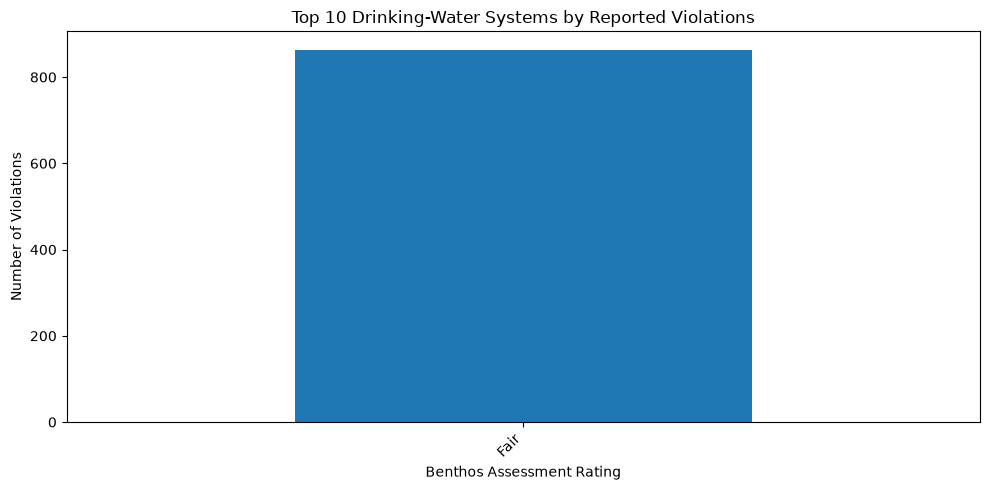

In [ ]:
violations = (
    piw_benthos_report
    .groupby("Latest_Rating")["# of Violations"]
    .max()
    .sort_values(ascending=False)
    .head(10)
)

violations.plot(kind="bar", figsize=(10, 5))

plt.title("Top 10 Drinking-Water Systems by Reported Violations")
plt.xlabel("Benthos Assessment Rating")
plt.ylabel("Number of Violations")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

Seems like number of violations and benthos rating don't exhibit a visual pattern. There is only one bar because both of the closest benthos assessments to the gas plant had fair ratings oopsie. Lets test this relationship with all assessments and water reports without considering gas plants

In [14]:
benthos_violations =  benthos.merge(water_report, left_on ="County", right_on= "Counties Served", how="left")
benthos_violations

,Site_ID,View_Details,Water_Body,Location,County,Sampled_Rating,Longitude,Latitude,Latest_Rating,Study_Type,...,PWS ID,PWS Name,PWS Type,Primary Source,Counties Served,Cities Served,Population Served Count,# of Facilities,# of Violations,# of Site Visits
0,BB290,"<a href=""http://www.ncwater.org/?page=672&Site...",AVENTS CR,SR 1418,Harnett,<br />28 May 2013 / Excellent<br />23 Apr 2007...,-78.910000,35.487222,Excellent,Special Study,...,NC0343015,"ANGIER, TOWN OF",Community water system,Surface water purchased,Harnett,ANGIER,"13,302",5.0,17.0,77.0
1,BB290,"<a href=""http://www.ncwater.org/?page=672&Site...",AVENTS CR,SR 1418,Harnett,<br />28 May 2013 / Excellent<br />23 Apr 2007...,-78.910000,35.487222,Excellent,Special Study,...,NC0343020,"COATS, TOWN OF",Community water system,Surface water purchased,Harnett,COATS,"3,052",5.0,12.0,67.0
2,BB290,"<a href=""http://www.ncwater.org/?page=672&Site...",AVENTS CR,SR 1418,Harnett,<br />28 May 2013 / Excellent<br />23 Apr 2007...,-78.910000,35.487222,Excellent,Special Study,...,NC0343010,"DUNN, CITY OF",Community water system,Surface water,Harnett,ERWIN,"12,497",7.0,4.0,117.0
3,BB290,"<a href=""http://www.ncwater.org/?page=672&Site...",AVENTS CR,SR 1418,Harnett,<br />28 May 2013 / Excellent<br />23 Apr 2007...,-78.910000,35.487222,Excellent,Special Study,...,NC5043001,FORT BRAGG LINDEN OAKS,Community water system,Surface water purchased,Harnett,CAMERON,"3,733",3.0,3.0,22.0
4,BB290,"<a href=""http://www.ncwater.org/?page=672&Site...",AVENTS CR,SR 1418,Harnett,<br />28 May 2013 / Excellent<br />23 Apr 2007...,-78.910000,35.487222,Excellent,Special Study,...,NC0343045,HARNETT REGIONAL WATER,Community water system,Surface water,Harnett,LILLINGTON,"121,885",8.0,11.0,205.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
270322,JB363,"<a href=""http://www.ncwater.org/?page=672&Site...",JUMPING RUN CR,"SITE 1, OFF SR 1613",Alexander,<br />28 Oct 2013 / Not Rated,-81.137066,35.890630,Not Rated,Special Study,...,NC0102592,PLEASANT HILL BAPTIST CH,Transient non-community system,Ground water,Alexander,TAYLORSVILLE,80,5.0,7.0,40.0
270323,JB363,"<a href=""http://www.ncwater.org/?page=672&Site...",JUMPING RUN CR,"SITE 1, OFF SR 1613",Alexander,<br />28 Oct 2013 / Not Rated,-81.137066,35.890630,Not Rated,Special Study,...,NC0102484,POPLAR SPRING BAPTIST CHURCH,Transient non-community system,Ground water,Alexander,TAYLORSVILLE,120,4.0,3.0,32.0
270324,JB363,"<a href=""http://www.ncwater.org/?page=672&Site...",JUMPING RUN CR,"SITE 1, OFF SR 1613",Alexander,<br />28 Oct 2013 / Not Rated,-81.137066,35.890630,Not Rated,Special Study,...,NC0102418,RIVERS EDGE MARINA,Transient non-community system,Ground water,Alexander,HICKORY,50,3.0,4.0,38.0
270325,JB363,"<a href=""http://www.ncwater.org/?page=672&Site...",JUMPING RUN CR,"SITE 1, OFF SR 1613",Alexander,<br />28 Oct 2013 / Not Rated,-81.137066,35.890630,Not Rated,Special Study,...,NC0102447,SUGARLOAF APPLEHOUSE,Transient non-community system,Ground water,Alexander,TAYLORSVILLE,50,3.0,20.0,29.0


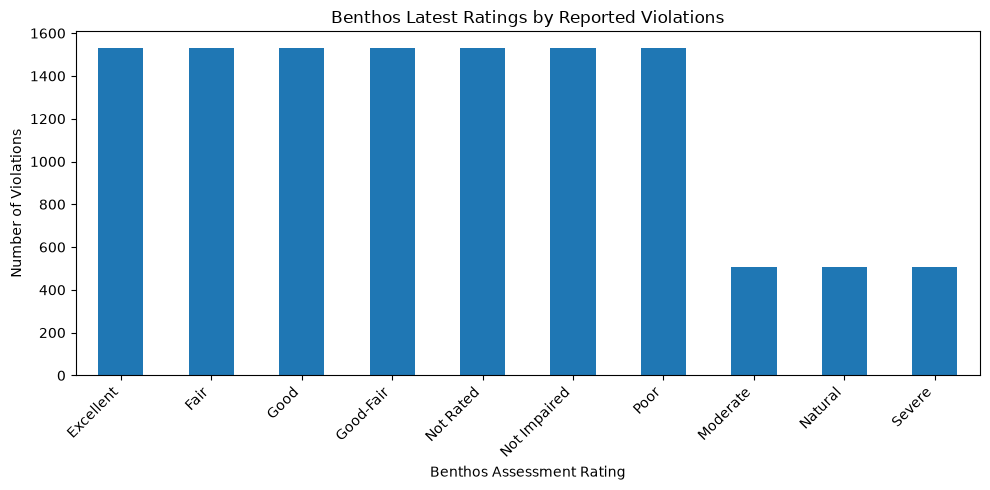

In [15]:
violations = (
    benthos_violations
    .groupby("Latest_Rating")["# of Violations"]
    .max()
    .sort_values(ascending=False)
    .head(10)
)

violations.plot(kind="bar", figsize=(10, 5))

plt.title("Benthos Latest Ratings by Reported Violations")
plt.xlabel("Benthos Assessment Rating")
plt.ylabel("Number of Violations")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

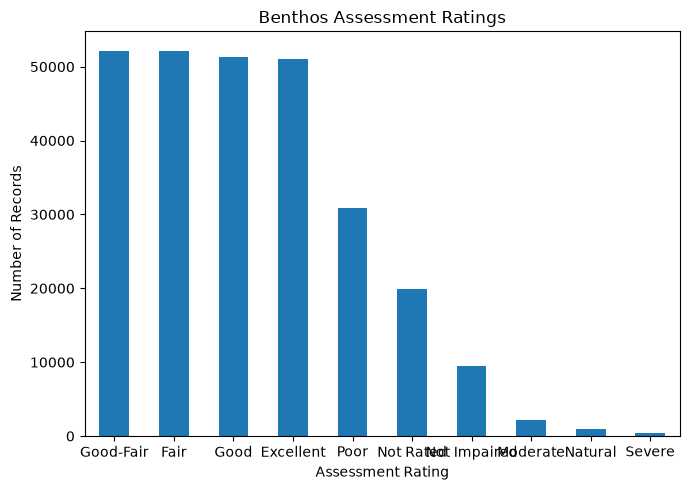

In [ ]:
rating_counts = benthos_violations["Latest_Rating"].value_counts()

rating_counts.plot(kind="bar", figsize=(7, 5))

plt.title("Benthos Assessment Ratings")
plt.xlabel("Assessment Rating")
plt.ylabel("Number of Records")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

Looks like theres not much of relationship between latest benthos rating and number of violations, however multiple benthos assessments got joined to one water facility, lets do a nearest join

In [17]:
benthos_near_reports = gpd.sjoin_nearest(benthos, water_report, how="right", distance_col="feet")

ValueError: 'right_df' should be GeoDataFrame, got <class 'pandas.DataFrame'>

Right, we can't do that because water_reports is a csv

In [18]:
counties

,OBJECTID,County,FIPS,Rec_Survey,NCGS_url,ck_date,Shape__Area,Shape__Length,GlobalID,geometry
0,1,Alamance,001,Recorded survey data is available. Visit North...,https://ncem-gis.maps.arcgis.com/apps/webappvi...,2025-01-13 00:00:00+00:00,1.210717e+10,476733.362073,acd66e2b-e702-4b3a-82c1-eb86e12d3804,"POLYGON ((1923604.345 881802.091, 1923341.195 ..."
1,2,Alexander,003,Recorded survey data is available. Visit North...,https://ncem-gis.maps.arcgis.com/apps/webappvi...,2025-01-13 00:00:00+00:00,7.343450e+09,387342.137292,6a1dac25-2574-4182-b77b-0074a5482dac,"POLYGON ((1374326.862 744227.342, 1374262.766 ..."
2,3,Alleghany,005,No recent survey data available,,2011-11-29 00:00:00+00:00,6.576362e+09,439166.717185,d8e726fa-ac7d-4212-a981-6ea0b111cee0,"POLYGON ((1336457.551 959892.73, 1336578.943 9..."
3,4,Anson,007,No recent survey data available,,2011-11-29 00:00:00+00:00,1.497020e+10,575503.754866,e4518706-732a-4abe-9079-9de6523b4747,"POLYGON ((1618558.995 528615.286, 1618623 5286..."
4,5,Ashe,009,Recorded survey data is available. Visit North...,https://ncem-gis.maps.arcgis.com/apps/webappvi...,2025-01-13 00:00:00+00:00,1.193926e+10,520084.244333,6d39c7ea-b7f4-4ac8-be47-65dfe4a46074,"POLYGON ((1269470.886 915478.909, 1266824.855 ..."
...,...,...,...,...,...,...,...,...,...,...
95,96,Wayne,191,Recorded survey data is available. Visit North...,https://ncem-gis.maps.arcgis.com/apps/webappvi...,2025-01-13 00:00:00+00:00,1.554411e+10,579779.305793,d8af9501-60d9-48eb-95b0-fe5d25bfa0c2,"POLYGON ((2297704.655 669585.811, 2297802.27 6..."
96,97,Wilkes,193,Recorded survey data is available. Visit North...,https://ncem-gis.maps.arcgis.com/apps/webappvi...,2025-01-13 00:00:00+00:00,2.111152e+10,718180.039408,69241b1a-84e3-4fa4-8b2e-197d151c8dbe,"POLYGON ((1319003.919 828582.081, 1318920.299 ..."
97,98,Wilson,195,Recorded survey data is available. Visit North...,https://ncem-gis.maps.arcgis.com/apps/webappvi...,2025-01-13 00:00:00+00:00,1.039961e+10,430628.770432,2b485dcd-086d-441f-9e9c-c33b82b18800,"POLYGON ((2350081.935 670058.039, 2349948.507 ..."
98,99,Yadkin,197,Recorded survey data is available. Visit North...,https://ncem-gis.maps.arcgis.com/apps/webappvi...,2025-01-13 00:00:00+00:00,9.415514e+09,452687.390790,1434800b-c873-4475-8865-cea54663d8f2,"POLYGON ((1557884.733 838963.611, 1557598.265 ..."


In [21]:
water_reportsp = counties.merge(water_report, left_on ="County", right_on= "Counties Served", how="right")
water_reportsp

,OBJECTID,County,FIPS,Rec_Survey,NCGS_url,ck_date,Shape__Area,Shape__Length,GlobalID,geometry,PWS ID,PWS Name,PWS Type,Primary Source,Counties Served,Cities Served,Population Served Count,# of Facilities,# of Violations,# of Site Visits
0,47,Hoke,093,Recorded survey data is available. Visit North...,https://ncem-gis.maps.arcgis.com/apps/webappvi...,2011-11-29 00:00:00+00:00,1.091606e+10,535987.465253,a8e23dae-b8d7-4735-9d53-5f5e1efcd2ba,"POLYGON ((1895618.759 396358.827, 1895637.39 3...",NC0347102,401 MOBILE HOME PARK,Community water system,Ground water,Hoke,RAEFORD,75,4,74,52
1,22,Clay,043,No recent survey data available,,2011-11-29 00:00:00+00:00,6.153363e+09,449623.071327,99129a7a-62a3-4445-a370-928c6610ae51,"POLYGON ((546043.083 534194.548, 546162.408 53...",NC1022007,64 EAST APARTMENTS,Community water system,Ground water,Clay,HAYESVILLE,50,4,1,6
2,92,Wake,183,Recorded survey data is available. Visit North...,https://ncem-gis.maps.arcgis.com/apps/webappvi...,2025-01-13 00:00:00+00:00,2.388836e+10,702032.705904,ae5eace8-821c-45f8-9668-39da64e69312,"POLYGON ((2027828.351 770899.482, 2028505.034 ...",NC0392107,70 EAST MOBILE ACRES,Community water system,Ground water,Wake,GARNER,140,7,26,21
3,92,Wake,183,Recorded survey data is available. Visit North...,https://ncem-gis.maps.arcgis.com/apps/webappvi...,2025-01-13 00:00:00+00:00,2.388836e+10,702032.705904,ae5eace8-821c-45f8-9668-39da64e69312,"POLYGON ((2027828.351 770899.482, 2028505.034 ...",NC0392222,A COUNTRY PLACE,Community water system,Ground water,Wake,WAKE FOREST,89,10,20,19
4,63,Moore,125,Recorded survey data is available. Visit North...,https://ncem-gis.maps.arcgis.com/apps/webappvi...,2011-11-29 00:00:00+00:00,1.966796e+10,762524.818203,56a571ec-461a-456d-aa5f-60d29b66dfbc,"POLYGON ((1862690.297 471131.636, 1862674.131 ...",NC0363020,"ABERDEEN, TOWN OF",Community water system,Ground water,Moore,ABERDEEN,"12,473",46,28,151
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4985,97,Wilkes,193,Recorded survey data is available. Visit North...,https://ncem-gis.maps.arcgis.com/apps/webappvi...,2025-01-13 00:00:00+00:00,2.111152e+10,718180.039408,69241b1a-84e3-4fa4-8b2e-197d151c8dbe,"POLYGON ((1319003.919 828582.081, 1318920.299 ...",NC0197413,ZION HILL BAPTIST CHURCH,Transient non-community system,Ground water,Wilkes,BOOMER,25,5,3,13
4986,45,Henderson,089,Recorded survey data is available. Visit North...,https://ncem-gis.maps.arcgis.com/apps/webappvi...,2011-11-29 00:00:00+00:00,1.045732e+10,599031.945568,2bcd320d-cb79-4803-8ccd-5b0401f14f8a,"POLYGON ((931593.348 527105.327, 931485.488 52...",NC0145599,ZION HILL BAPTIST CHURCH,Transient non-community system,Ground water,Henderson,ZIRCONIA,100,3,11,17
4987,59,McDowell,111,Recorded survey data is available. Visit North...,https://ncem-gis.maps.arcgis.com/apps/webappvi...,2025-01-13 00:00:00+00:00,1.240885e+10,587707.153227,6418dffb-5078-4792-8e6e-1a889285fa7a,"POLYGON ((1160337.104 676141.324, 1160257.341 ...",NC0156521,ZION HILL BAPTIST CHURCH,Transient non-community system,Ground water,McDowell,MARION,225,3,50,15
4988,11,Buncombe,021,No recent survey data available,,2011-11-29 00:00:00+00:00,1.839115e+10,790738.319016,f2b89e33-3778-4b71-a7ba-e2f91ddc268b,"POLYGON ((1027781.158 641185.709, 1027702.748 ...",NC1011042,ZION HILL FAMILY LIFE CENTER,Transient non-community system,Ground water,Buncombe,LEICESTER,200,3,1,6


In [23]:
water_report['Counties Served'].value_counts()

Counties Served
Wake        440
Gaston      245
Guilford    207
Rowan       193
Catawba     146
           ... 
Jones         3
Pamlico       3
Chowan        2
Gates         2
Camden        1
Name: count, Length: 100, dtype: int64

There are multiple PWS within one county, this makes it hard to assign one benthos rating to a facility, lets just see which counties have the most violations and bad benthos ratings

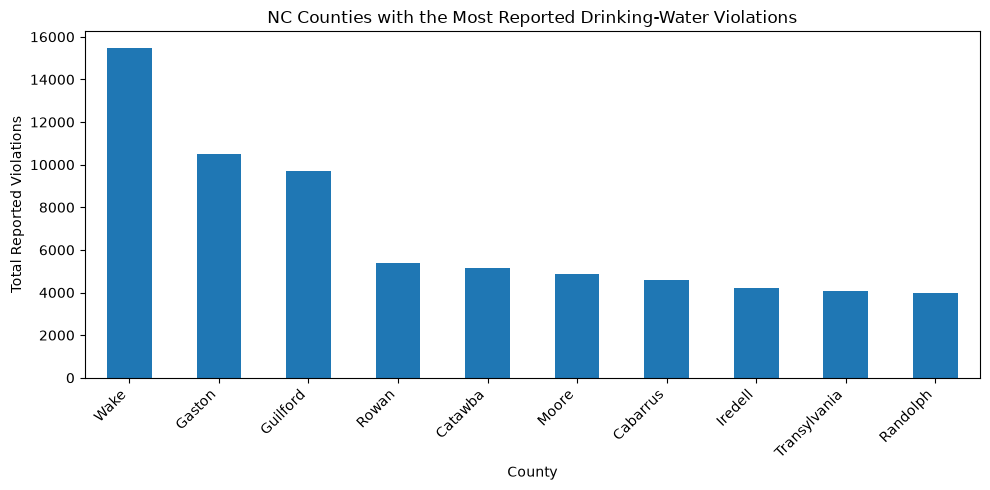

In [24]:
# Convert violations to numeric
water_report["# of Violations"] = pd.to_numeric(
    water_report["# of Violations"],
    errors="coerce"
)

# Sum violations by county
county_violations = (
    water_report
    .groupby("Counties Served")["# of Violations"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

county_violations.plot(kind="bar", figsize=(10, 5))

plt.title("NC Counties with the Most Reported Drinking-Water Violations")
plt.xlabel("County")
plt.ylabel("Total Reported Violations")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

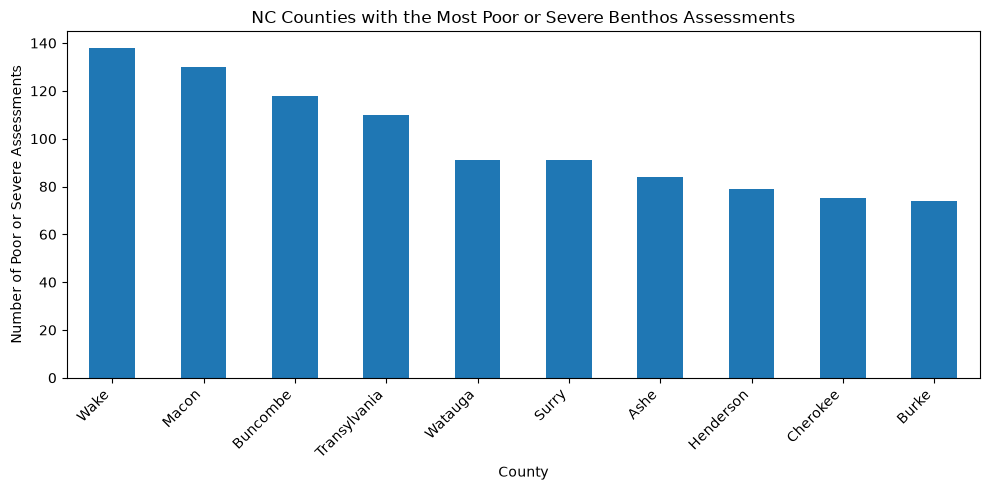

In [28]:
# Count poor and severe assessments by county
benthos_counts = (
    benthos
    .groupby("County")["Latest_Rating"]
    .count()
    .sort_values(ascending=False)
    .head(10)
)

benthos_counts.plot(kind="bar", figsize=(10, 5))

plt.title("NC Counties with the Most Poor or Severe Benthos Assessments")
plt.xlabel("County")
plt.ylabel("Number of Poor or Severe Assessments")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

I used ChatGPT to help format the bar graphs, with the object creation andlayout design

Turns out Wake county has the worst water quality accross the board! Guilford and Catawba were both identified in the top five for violations, which is where the gas plants existed inside of water supply watersheds, but they didn't have the most severe benthos ratings. However there is overlap in these 2 bar graphs, maybe there is a different underlying issue affecting water than gas sites.